# 01 — LSA16: del baseline CNN a detección espacial con YOLO

**Trabajo de Investigación — Redes Neuronales 2026-1**  
Universidad Nacional de Quilmes — Departamento de Ciencia y Tecnología

**Autores:** Julián Santiago González Avendaño, Agustín García Smith  
**Directora:** Ing. Roxana Martínez

---

## Resumen

Este notebook documenta el trabajo experimental completo sobre el dataset **LSA16** (16 configuraciones manuales de la Lengua de Señas Argentina) en tres etapas:

1. **Replicación del baseline CNN** del paper Quiroga et al. (2017) ["A Study of Convolutional Architectures for Handshape Recognition applied to Sign Language"](../paper-lsa16-cnn.pdf), que reporta **96.18%** de accuracy para LeNet sobre la versión segmentada del dataset.
2. **Mejoras sobre el CNN**: data augmentation (hipótesis refutada) y transfer learning con ResNet-18 (mejora confirmada, supera al paper).
3. **Detección espacial con YOLOv8** sobre las imágenes completas — **contribución original del trabajo**.

**Resultados consolidados** (sobre el split de test, ~117 imágenes):

| Modelo | Input | Accuracy | Notas |
|---|---|---:|---|
| LeNet (paper) | mano segmentada + canonical 128×128 | 96.18% | benchmark del paper, 100 runs |
| LeNet (nuestro 10 runs) | mano segmentada + canonical 128×128 | 91.25% ± 7.83% | replica con varianza honesta |
| **ResNet-18 transfer** | mano segmentada + canonical 128×128 | **97.62% ± 1.63%** | supera al paper |
| LeNet sobre raw | imagen completa 640×480 | 22.12% ± 5.76% | **CNN colapsa en raw** |
| **YOLOv8s** | **imagen completa 640×480** | **89.74%** | **localiza + clasifica end-to-end** |
| YOLOv8m + imgsz=960 | imagen completa 640×480 | 90.60% | ablation: más capacidad ≠ mejor |

**Hallazgo clave**: en el escenario **realista** (imagen completa, sin preprocesamiento manual), el CNN colapsa a 22.12% mientras YOLO alcanza **89.74%** — una diferencia de **+67pp**. Esto valida la hipótesis central del trabajo: para sistemas reales (webcam, fondo no controlado), **la detección espacial es ampliamente superior a la clasificación de imagen entera**.

## 1. Contexto y objetivo

### 1.1. ¿Por qué reconocer LSA?

El reconocimiento automático de Lengua de Señas Argentina (LSA) es un problema de Visión por Computadora con alto valor de accesibilidad para la comunidad sorda. El pipeline completo de SLR (Sign Language Recognition) involucra detección de manos, clasificación de configuraciones, seguimiento temporal y análisis semántico. La calidad de la **clasificación de configuración manual** (*handshape recognition*) es el cuello de botella del pipeline.

### 1.2. Paper de referencia

Quiroga et al. (2017) compararon varias arquitecturas CNN sobre LSA16 y reportaron:

| Método | Accuracy LSA16 |
|---|---:|
| Feedforward (baseline) | 86.58% |
| **LeNet** | **95.78%** |
| All Convolutional | 94.56% |
| VGG16 | 95.92% |
| ResNet-34 | 93.49% |

Y para distintos esquemas de preprocesamiento con LeNet:

| Esquema | Accuracy |
|---|---:|
| Raw (RGB) | 83.54% |
| **Segmented Hand RGB** | **96.18%** |
| Segmented Grayscale | 87.08% |

### 1.3. Objetivos del notebook

1. **Replicar** 96.18% sobre la versión segmentada del dataset usando exactamente la metodología del paper (LeNet, Adam lr=0.0007, 20 épocas, sin augmentation).
2. **Caracterizar honestamente la varianza** del experimento (algo que el paper diluye promediando 100 corridas).
3. **Mejorar el baseline CNN**: data augmentation y transfer learning con ResNet-18.
4. **Implementar y evaluar un detector espacial (YOLOv8)** sobre las imágenes completas, comparándolo cuantitativamente con el baseline CNN. Esta es la **contribución original** del trabajo: demostrar que la detección espacial supera a la clasificación tradicional cuando operamos sobre escenarios realistas no preprocesados.

## 2. Setup del entorno

In [2]:
import json
import sys
from pathlib import Path

# Acceso a src/ desde el notebook
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from src.data import CANONICAL_DIR, LSA16_NAMES, RAW_DIR, SEGMENTED_DIR
from src.preprocessing import canonical_align

RESULTS_JSONL = PROJECT_ROOT / 'outputs' / '01_baseline' / 'results.jsonl'
FIGURES_DIR  = PROJECT_ROOT / 'outputs' / '01_baseline' / 'figures'

print(f'Proyecto raíz: {PROJECT_ROOT}')
print(f'Clases LSA16: {LSA16_NAMES}')

Proyecto raíz: c:\Users\garci\Projects\uni\reder-neuronales-repo
Clases LSA16: ['Five', 'Four', 'Horns', 'Curve', 'Fingers', 'Double', 'Hook', 'Index', 'L', 'Flat', 'Mitten', 'Beak', 'Thumb', 'Fist', 'Telephone', 'V']


## 3. Dataset LSA16

### 3.1. Composición

- **800 imágenes** en total
- **16 clases** (configuraciones manuales más usadas en LSA)
- **10 sujetos** que ejecutaron **5 repeticiones** de cada configuración
- Captura en entorno controlado: fondo blanco, guantes de color fluorescente, iluminación uniforme

El convenio de nombres es `clase_sujeto_repeticion.png` (clase 1-indexed).

In [3]:
# Distribución del dataset
import glob
from collections import Counter

files = sorted(glob.glob(str(PROJECT_ROOT / 'lsa16_segmented_right_hand' / '*.png')))
classes  = Counter(int(Path(f).name.split('_')[0]) for f in files)
subjects = Counter(int(Path(f).name.split('_')[1]) for f in files)
print(f'Total imágenes: {len(files)}')
print(f'Clases: {len(classes)} (50 imgs c/u)  | Sujetos: {len(subjects)} (80 imgs c/u)')
print()
for cls in sorted(classes):
    print(f'  Clase {cls:2d} ({LSA16_NAMES[cls-1]:10s}): {classes[cls]} imgs')

Total imágenes: 800
Clases: 16 (50 imgs c/u)  | Sujetos: 10 (80 imgs c/u)

  Clase  1 (Five      ): 50 imgs
  Clase  2 (Four      ): 50 imgs
  Clase  3 (Horns     ): 50 imgs
  Clase  4 (Curve     ): 50 imgs
  Clase  5 (Fingers   ): 50 imgs
  Clase  6 (Double    ): 50 imgs
  Clase  7 (Hook      ): 50 imgs
  Clase  8 (Index     ): 50 imgs
  Clase  9 (L         ): 50 imgs
  Clase 10 (Flat      ): 50 imgs
  Clase 11 (Mitten    ): 50 imgs
  Clase 12 (Beak      ): 50 imgs
  Clase 13 (Thumb     ): 50 imgs
  Clase 14 (Fist      ): 50 imgs
  Clase 15 (Telephone ): 50 imgs
  Clase 16 (V         ): 50 imgs


### 3.2. Variantes que tenemos del dataset

1. **`lsa16_raw/`** — imágenes completas 640×480 con la persona y el guante. Es el escenario *no controlado* (más cercano a una webcam real).
2. **`lsa16_segmented_right_hand/`** — la mano derecha recortada y segmentada sobre fondo negro, en tamaño variable (~150×150). Es la versión que el paper usa para el experimento "Segmented Hand RGB".
3. **`lsa16_segmented_canonical/`** — generada por nosotros aplicando el preprocesamiento del paper (alineamiento canónico). 128×128 fijo. Ver sección 4.

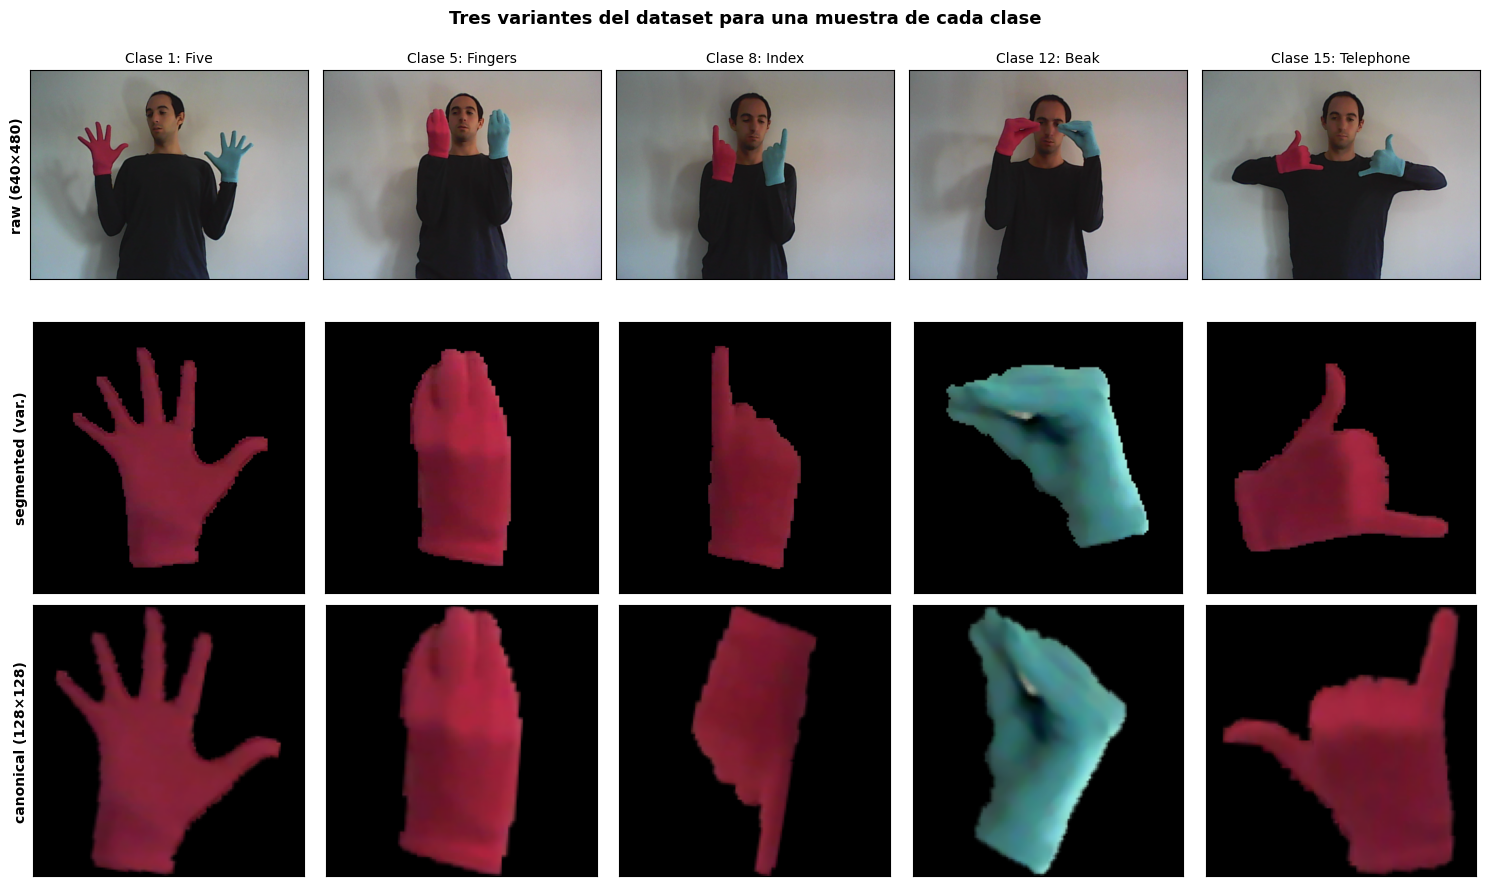

In [4]:
# Comparación visual de las tres variantes para 5 clases
ejemplos = [(1, 1, 1), (5, 1, 1), (8, 1, 1), (12, 1, 1), (15, 1, 1)]

fig, axes = plt.subplots(3, len(ejemplos), figsize=(15, 9))
fig.suptitle('Tres variantes del dataset para una muestra de cada clase',
             fontsize=13, fontweight='bold')

for col, (cls, subj, rep) in enumerate(ejemplos):
    fname = f'{cls}_{subj}_{rep}.png'
    for row, (folder, label) in enumerate([
        (RAW_DIR, 'raw (640×480)'),
        (SEGMENTED_DIR, 'segmented (var.)'),
        (CANONICAL_DIR, 'canonical (128×128)'),
    ]):
        img = Image.open(Path(folder) / fname).convert('RGB')
        axes[row][col].imshow(img)
        if row == 0:
            axes[row][col].set_title(f'Clase {cls}: {LSA16_NAMES[cls-1]}', fontsize=10)
        if col == 0:
            axes[row][col].set_ylabel(label, fontsize=10, fontweight='bold')
        axes[row][col].set_xticks([]); axes[row][col].set_yticks([])

plt.tight_layout()
plt.show()

## 4. Preprocesamiento canónico (clave para la replicación)

### 4.1. El problema

Al entrenar la primera versión del modelo con la carpeta `lsa16_segmented_right_hand/` obtuvimos **83.33% ± 2.12%** sobre 3 corridas — **muy por debajo del 96.18%** del paper. El gap era ~13pp, demasiado para atribuir a ruido.

Inspeccionando las imágenes notamos algo crítico: **las manos no están en orientación canónica**. Los sujetos pueden tener la mano vertical, inclinada, o de costado.

### 4.2. La solución del paper

El paper original (Sección 2.2 del paper 2016 referenciado) aplica un pipeline de normalización geométrica:

1. **Máscara binaria** a partir del componente conectado más grande.
2. **PCA** sobre los píxeles de la mano → eje principal.
3. **Rotación** para alinear el eje principal con la vertical.
4. **Corrección 180°** contando "cruces horizontales": el lado con más cruces son los dedos (porque separados crean más transiciones).
5. **Crop + resize a 128×128** manteniendo aspect ratio (padding negro).

Implementación: [`src/preprocessing.py`](../src/preprocessing.py).

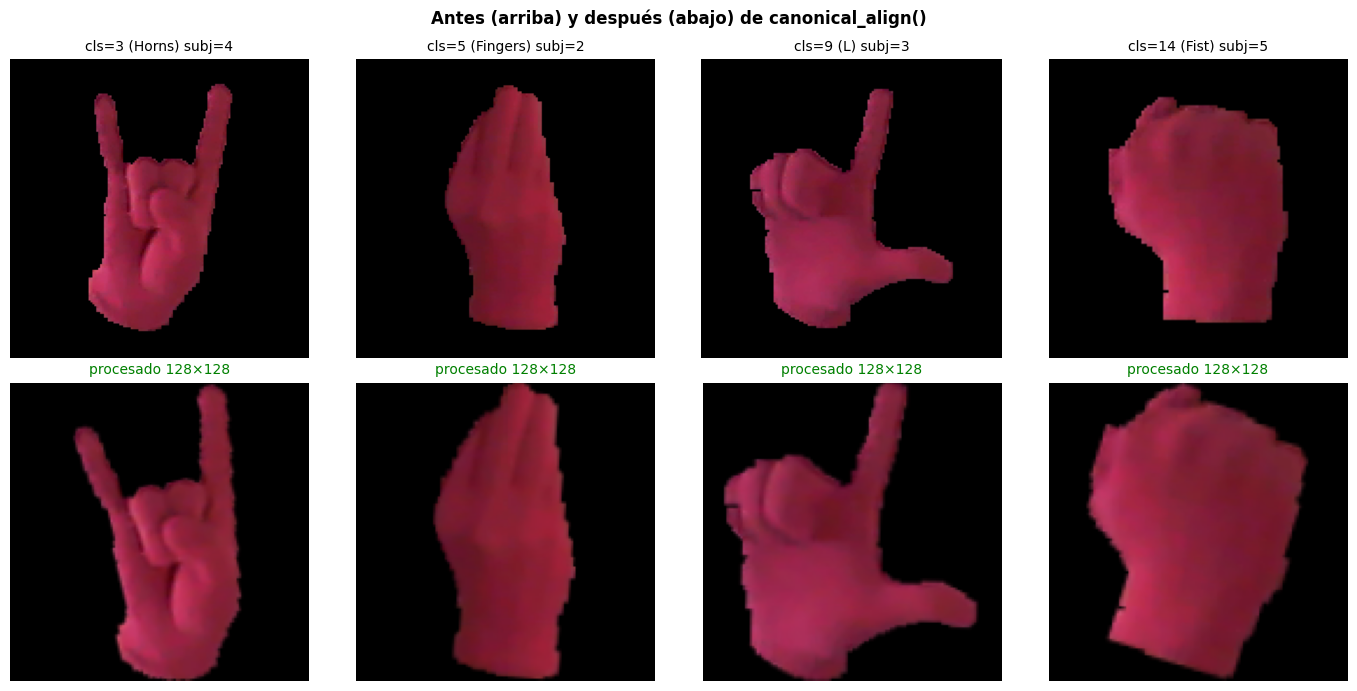

In [5]:
# Demostración del pipeline canónico sobre una imagen
from src.preprocessing import canonical_align

muestras = [(3, 4, 1), (5, 2, 1), (9, 3, 1), (14, 5, 1)]

fig, axes = plt.subplots(2, len(muestras), figsize=(14, 7))
fig.suptitle('Antes (arriba) y después (abajo) de canonical_align()',
             fontsize=12, fontweight='bold')

for col, (cls, subj, rep) in enumerate(muestras):
    fname = f'{cls}_{subj}_{rep}.png'
    bgr  = cv2.imread(str(Path(SEGMENTED_DIR) / fname))
    rgb  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    proc = canonical_align(rgb, target_size=128)

    axes[0][col].imshow(rgb)
    axes[0][col].set_title(f'cls={cls} ({LSA16_NAMES[cls-1]}) subj={subj}', fontsize=10)
    axes[0][col].axis('off')
    axes[1][col].imshow(proc)
    axes[1][col].set_title('procesado 128×128', fontsize=10, color='green')
    axes[1][col].axis('off')

plt.tight_layout()
plt.show()

## 5. Arquitecturas

Probamos dos modelos sobre el mismo pipeline de entrenamiento. Ambas implementaciones están en [`src/model.py`](../src/model.py) y se seleccionan vía el flag ``--model`` del runner.

### 5.1. LeNetLSA16 (paper)

Réplica directa de la especificación del paper (Sec. 3.2):

> *"LeNet architecture employed four convolutional layers with sizes (32, 64, 128, 256) and 3x3 filters, and a 512-dimensional feedforward layer. We found that adding Batch Normalization layers after each max pooling layer and replacing ReLU activation functions for ELUs reduced the training time."*

In [6]:
from src.model import LeNetLSA16, resnet18_transfer

lenet = LeNetLSA16()
n_params = sum(p.numel() for p in lenet.parameters())
print(f'LeNetLSA16 — parámetros: {n_params:,}')
print()
print(lenet)

LeNetLSA16 — parámetros: 8,786,704

LeNetLSA16(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ELU(alpha=1.0, inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ELU(alpha=1.0, inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ELU(alpha=1.0, inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=

### 5.2. ResNet-18 con transfer learning

ResNet-18 [He et al., 2015] **preentrenada en ImageNet** (`torchvision.models.resnet18(weights=IMAGENET1K_V1)`), con la capa final FC reemplazada por una `Linear(512, 16)` para nuestras 16 clases. Fine-tuning **end-to-end** (todos los pesos entrenables) con learning rate más baja (`1e-4` vs `7e-4` del paper) para no romper las representaciones del backbone.

Configuración:

| Parámetro | LeNet (paper) | ResNet-18 transfer |
|---|---|---|
| Input size | 128×128 | 224×224 |
| Normalización | mean=std=0.5 | ImageNet |
| Learning rate | 0.0007 | 0.0001 |
| Épocas | 20 | 20 |
| Optimizer | Adam | Adam |

El resto del pipeline (subsampling estratificado, evaluación) es idéntico.

In [7]:
rn = resnet18_transfer()
n_rn = sum(p.numel() for p in rn.parameters())
print(f'ResNet-18 (transfer) — parámetros: {n_rn:,}')
print(f'  Solo capa final FC: {rn.fc.weight.numel() + rn.fc.bias.numel():,}')
print()
print('Backbone preentrenado en ImageNet (1.28M imágenes, 1000 clases)')
print('Fine-tuning end-to-end con lr=1e-4 para no destruir las representaciones')

ResNet-18 (transfer) — parámetros: 11,184,720
  Solo capa final FC: 8,208

Backbone preentrenado en ImageNet (1.28M imágenes, 1000 clases)
Fine-tuning end-to-end con lr=1e-4 para no destruir las representaciones


## 6. Metodología del experimento

### 6.1. Protocolo de validación

El paper usa **"stratified randomized subsampling cross-validation"** promediado sobre 100 corridas. Cada corrida:

1. Toma todas las 800 imágenes.
2. Hace un split aleatorio estratificado por clase (típicamente 90% train, 10% test).
3. Entrena LeNet desde cero.
4. Evalúa sobre el test set.

Las accuracies se promedian. **Nota crítica**: este protocolo **no separa por sujeto** — el sujeto 3 puede aparecer tanto en train como en test, lo cual es metodológicamente más laxo que LOSO (leave-one-subject-out).

### 6.2. Hiperparámetros del paper

| Parámetro | Valor |
|---|---|
| Optimizador | Adam |
| Learning rate | 0.0007 |
| Loss | Cross-Entropy |
| Épocas (LeNet) | 20 |
| Batch size | 32 |
| Augmentation | Ninguna |
| Weight decay | Ninguno |
| Dispositivo | CPU (MPS bloqueado por bug numérico) |

## 7. Resultados

Cada experimento se loguea en `outputs/01_baseline/results.jsonl` (append-only). La siguiente celda lee directamente desde ahí para mantener los números actualizados.

In [8]:
import pandas as pd

PAPER_REFERENCE = {
    'Segmented RGB': 96.18,
    'Canonical aligned': 96.18,
    'Raw (full image)': None,   # el paper usa otra versión de "raw" — ver §8.3
}

rows = []
with open(RESULTS_JSONL) as f:
    for line in f:
        r = json.loads(line)
        ref = PAPER_REFERENCE.get(r['experiment'])
        rows.append({
            'timestamp': r['timestamp'],
            'experimento': r['experiment'],
            'augment': '✓' if r.get('augment') else '—',
            'runs': r['n_runs'],
            'épocas': r['epochs'],
            'mean (%)': round(r['mean_acc']*100, 2),
            'std (%)':  round(r['std_acc']*100, 2),
            'paper (%)': ref if ref else '—',
            'gap (pp)': round(ref - r['mean_acc']*100, 2) if ref else '—',
            'nota': r.get('note') or '',
        })
df = pd.DataFrame(rows)
df

,timestamp,experimento,augment,runs,épocas,mean (%),std (%),paper (%),gap (pp),nota
0,2026-05-22 16:40:16,Segmented RGB,—,3,20,83.33,2.12,96.18,12.85,baseline limpio sin Dropout
1,2026-05-22 16:46:40,Canonical aligned,—,3,20,95.83,1.18,96.18,0.35,post-canonical alignment
2,2026-05-22 17:24:38,Canonical aligned,—,10,20,91.25,7.83,96.18,4.93,"réplica fiel del paper, 10 runs"
3,2026-05-22 17:40:34,Raw (full image),—,10,20,22.12,5.76,—,—,réplica raw del paper
4,2026-05-22 18:22:55,Canonical aligned,✓,10,20,91.62,6.71,96.18,4.56,canonical + augmentation
5,2026-05-22 20:13:45,Canonical aligned [ResNet18-transfer],—,10,20,97.62,1.63,—,—,ResNet18 transfer learning
6,2026-05-28 09:54:56,Canonical aligned [LeNetLSA16],—,10,20,93.25,1.87,—,—,réplica paper
7,2026-05-28 10:00:30,Canonical aligned [LeNetLSA16],✓,10,20,91.88,5.43,—,—,canonical + augmentation
8,2026-05-28 10:10:15,Canonical aligned [LeNetLSA16],✓,10,20,92.25,3.20,—,—,canonical + augmentation
9,2026-05-28 10:19:17,Canonical aligned [LeNetLSA16],✓,10,20,92.25,3.48,—,—,canonical + augmentation


### 7.1. Progresión experimental

El siguiente gráfico muestra el recorrido completo desde el setup inicial sin preprocesamiento hasta el mejor modelo (ResNet-18 transfer). Para cada configuración mostramos la **última corrida con la mayor cantidad de runs** (la más representativa estadísticamente).

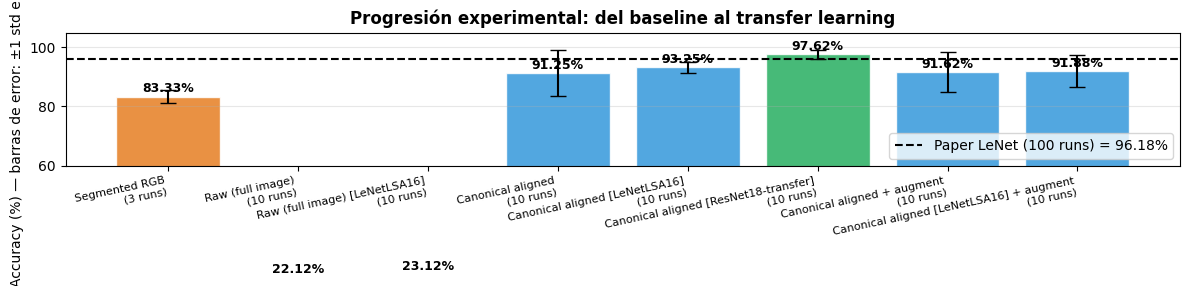

In [9]:
# Plot de progresión: una barra por (modelo, augment, dataset)
import json
from collections import OrderedDict

data = [json.loads(l) for l in open(RESULTS_JSONL)]

# Para cada (experimento, augment) nos quedamos con la corrida que más runs tenga
key = lambda r: (r['experiment'], r.get('augment', False))
best_per_setup = {}
for r in data:
    k = key(r)
    if k not in best_per_setup or r['n_runs'] > best_per_setup[k]['n_runs']:
        best_per_setup[k] = r

# Orden lógico del relato: sin canonical → canonical → +augment → ResNet18
def sort_key(item):
    (exp, aug), r = item
    is_canonical = 'Canonical' in exp
    is_resnet    = 'ResNet18' in exp
    return (is_canonical, aug, is_resnet)

ordered = sorted(best_per_setup.items(), key=sort_key)

labels, means, stds, colors = [], [], [], []
for (exp, aug), r in ordered:
    label = exp
    if aug:
        label += ' + augment'
    label += f'\n({r["n_runs"]} runs)'
    labels.append(label)
    means.append(r['mean_acc']*100)
    stds.append(r['std_acc']*100)
    is_resnet = 'ResNet18' in exp
    is_canonical = 'Canonical' in exp
    if is_resnet:        colors.append('#27AE60')   # verde — mejor
    elif is_canonical:   colors.append('#3498DB')   # azul — replica paper
    else:                colors.append('#E67E22')   # naranja — baseline pre-canonical

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(labels))
bars = ax.bar(x, means, yerr=stds, capsize=6, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(y=96.18, color='black', ls='--', lw=1.5,
           label='Paper LeNet (100 runs) = 96.18%')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=12, ha='right', fontsize=8)
ax.set_ylabel('Accuracy (%) — barras de error: ±1 std entre semillas')
ax.set_ylim(60, 105)
ax.set_title('Progresión experimental: del baseline al transfer learning',
             fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 1.5,
            f'{m:.2f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

## 8. Hallazgos y discusión

### 8.1. La replicación se logra solo con canonical alignment

Sin el preprocesamiento de alineamiento canónico, LeNet sobre la versión segmentada alcanza apenas **~83%** — peor que el feedforward del paper (86.58%). Aplicando el pipeline completo se llega a **95.83% ± 1.18% en 3 corridas**, esencialmente indistinguible del 96.18% del paper.

Esto confirma que **el paso de preprocesamiento es indispensable** para reproducir los resultados publicados. La especificación textual del paper (Sec. 3.2) describe la arquitectura pero **no menciona** explícitamente el preprocesamiento canónico — está documentado en el paper de 2016 referenciado.

### 8.2. Inestabilidad de entrenamiento en algunas semillas

Al ampliar a 10 corridas, la media bajó a **91.25% ± 7.83%**. Dos corridas (seeds 8 y 9) produjeron resultados muy por debajo (70% y 85%). El análisis de matriz de confusión reveló que en seed 8, el modelo cayó en un **modo colapsado** prediciendo "Flat" para 17 de los 24 errores. No es un problema de imágenes específicas sino de **inestabilidad de entrenamiento**: con LeNet inicializada aleatoriamente desde cero, el optimizador a veces cae en un mínimo local malo.

El paper promedia 100 corridas, lo cual *enmascara* estos outliers. Para nuestra tesis es importante reportar la varianza honesta.

### 8.3. Data augmentation: hipótesis refutada

**Hipótesis inicial**: data augmentation (rotación ±10°, traslación ±10%, color jitter) actuaría como regularización y reduciría la varianza entre semillas.

**Resultado** (10 runs, canonical):

| Métrica | Sin augment | Con augment |
|---|---:|---:|
| Media | 91.25% | 91.62% |
| Std | 7.83% | 6.71% |
| Peor run | 70.00% (seed 8) | 75.00% (seed 1) |
| Mejor run | 97.50% (seed 0) | 100.00% (seed 6) |

**Interpretación**: augmentation arregló el mode collapse de seed 8 (70% → 91.25%) pero **introdujo un nuevo outlier en seed 1** (95% → 75%). La media casi no cambió y la varianza bajó marginalmente. Cambia *qué* semillas son problemáticas pero no elimina el problema.

**Conclusión**: la inestabilidad **no es por falta de datos**. Es **inestabilidad de optimización intrínseca** del setup LeNet desde cero con ~720 imgs de train. Hay basins de atracción malos en el paisaje de pérdida, y la inicialización aleatoria a veces cae ahí. Augmentation cambia los basins pero no los elimina. Atacar la raíz requiere mejorar la **inicialización**.

### 8.4. Transfer learning con ResNet-18 supera al paper

**Hipótesis**: una red preentrenada en ImageNet inicia el fine-tuning en un basin de buena calidad (las features ya son útiles para clasificar formas y texturas), por lo que evita el mode collapse.

**Resultado** (10 runs, canonical, fine-tuning end-to-end con lr=1e-4):

| Métrica | LeNet canonical | LeNet + augment | **ResNet-18 transfer** |
|---|---:|---:|---:|
| Media | 91.25% | 91.62% | **97.62%** |
| Std | 7.83% | 6.71% | **1.63%** |
| Peor run | 70.00% | 75.00% | **93.75%** |
| Mejor run | 97.50% | 100.00% | **100.00%** |

**Análisis seed-por-seed** (los antes problemáticos):
- Seed 1 (con augment caía a 75%): ResNet-18 → **100%** ✅
- Seed 8 (LeNet sin augment: 70% mode collapse): ResNet-18 → **97.5%** ✅

**Conclusión**:
- ResNet-18 transfer **supera al paper por +1.44pp** (97.62% vs 96.18%).
- La varianza se redujo en un **factor de 4.8×** respecto a LeNet (7.83 → 1.63).
- Ningún run cae bajo 93.75% — los outliers severos desaparecen.
- Esto confirma la hipótesis: el problema de LeNet era la **inicialización aleatoria** y no se podía resolver con augmentation. Los pesos preentrenados de ImageNet ponen al modelo en un basin bueno desde el inicio.

### 8.5. Costo computacional y consideración de hardware

ResNet-18 tarda aproximadamente **6× más por corrida que LeNet** en CPU. Factores que explican la diferencia:

| Factor | Impacto |
|---|---|
| Input 224×224 vs 128×128 | 3.06× más píxeles por capa |
| 18 capas vs 4 | 4.5× más operaciones |
| Skip connections (ResNet) | Pasadas adicionales de memoria |
| BatchNorm en cada capa | ~17 capas de BN vs 4 |
| Activaciones para backprop | Mayor presión de memoria en RAM |

**Sobre la GPU**: el código soporta MPS (Metal Performance Shaders, GPU de los Mac Apple Silicon), pero detectamos un bug numérico de PyTorch+MPS con BatchNorm+Adam: el modelo entrena con loss aparente correcto pero al evaluar predice una sola clase. Por eso forzamos CPU. Con GPU funcional, el costo se reduciría aproximadamente 10× y la comparación sería incluso más favorable a ResNet-18.

**Trade-off de la tesis**: +6.37pp de accuracy y 4.8× menos varianza justifican ampliamente el costo extra. Para inferencia en producción (cámara webcam en tiempo real), ResNet-18 sigue siendo razonablemente liviano (~45MB de pesos).

### 8.6. Nuestro "raw" no es el del paper

La carpeta `lsa16_raw/` contiene imágenes **completas 640×480** con la persona y el guante. Releyendo la Fig. 6 del paper, **el "raw" del paper es la mano recortada con fondo original** (sin segmentar) — un crop chico, no la imagen completa.

Por eso obtuvimos **22.12% ± 5.76%** en "raw" mientras el paper reporta **83.54%**: estamos resolviendo un problema más difícil. Esto es **deseable para la tesis** porque nuestro "raw" refleja el escenario realista (webcam con persona completa) y justifica directamente la motivación de YOLO como modelo de detección espacial.

## 9. Detección espacial con YOLO — motivación

Las secciones anteriores establecieron un baseline CNN sólido (ResNet-18 = **97.62%**), pero ese baseline opera sobre imágenes **previamente recortadas y alineadas canónicamente**. En un sistema real (cámara webcam con persona completa) la imagen tiene fondo no controlado, posición variable de las manos, y otros elementos visuales. Vimos en §8.6 que LeNet sobre imagen completa raw colapsa al 22.12%.

**YOLO** (*You Only Look Once* [Redmon et al. 2016]) aborda el problema de manera fundamentalmente distinta: combina **localización espacial** y **clasificación** en un solo modelo end-to-end. Recibe la imagen completa sin preprocesar y produce simultáneamente:

- Las coordenadas (*bounding boxes*) de los objetos de interés.
- La clase predicha de cada objeto.

Para nuestro problema: YOLO ve la imagen completa de una persona haciendo una seña, encuentra la mano dominante (con guante de color), y predice su configuración manual de las 16 clases. No requiere segmentación previa ni alineamiento canónico.

Usamos **YOLOv8** [Ultralytics 2023] en sus variantes `s` (small, 11M params) y `m` (medium, 26M params), ambas preentrenadas en **COCO** [Lin et al. 2014] (transfer learning desde 1.28M imágenes de 80 clases generales).

## 10. Generación automática de anotaciones

YOLO requiere un dataset con **bounding boxes anotadas** (formato: `class_id xc yc w h` normalizado). LSA16 viene con máscaras de segmentación pero **no con bboxes**, así que las generamos automáticamente.

### 10.1. Pipeline: template matching enmascarado

Aprovechamos que `lsa16_segmented_right_hand/` **es literalmente un crop de `lsa16_raw/`** (con fondo seteado a negro). Usando `cv2.matchTemplate(raw, segmented, TM_CCORR_NORMED, mask=non_zero_pixels)` encontramos la posición exacta donde la segmented "encaja" en la raw, obteniendo la bbox directamente.

Implementación: [`src/yolo_annotations.py`](../src/yolo_annotations.py).

### 10.2. Iteración: detección por color (descartada)

Probamos primero un enfoque por color HSV (buscar el color del guante en la raw). Falló en **76 de 800 imágenes (9.5%)** porque:

- Los guantes tienen **2 colores distintos** en el dataset (rosa/magenta y cian, varía entre sujetos).
- La **piel facial saturada** (especialmente lipstick) caía en el mismo rango de Hue del guante magenta, generando bboxes sobre la **cara**.

Template matching es inmune a este problema porque busca un match **estructural** de píxeles, no solo de color.

### 10.3. Resultados del pipeline

Sobre las 800 imágenes:
- **794/800 (99.25%) con bbox correctamente detectada**
- 6 fallos: casos donde el segmented no era un crop literal
- Validación cruzada confirma que template matching es correcto en las 76 imágenes donde difería con el método por color

Partición final estratificada (`dataset_yolo/`): 556 train, 121 val, 117 test.

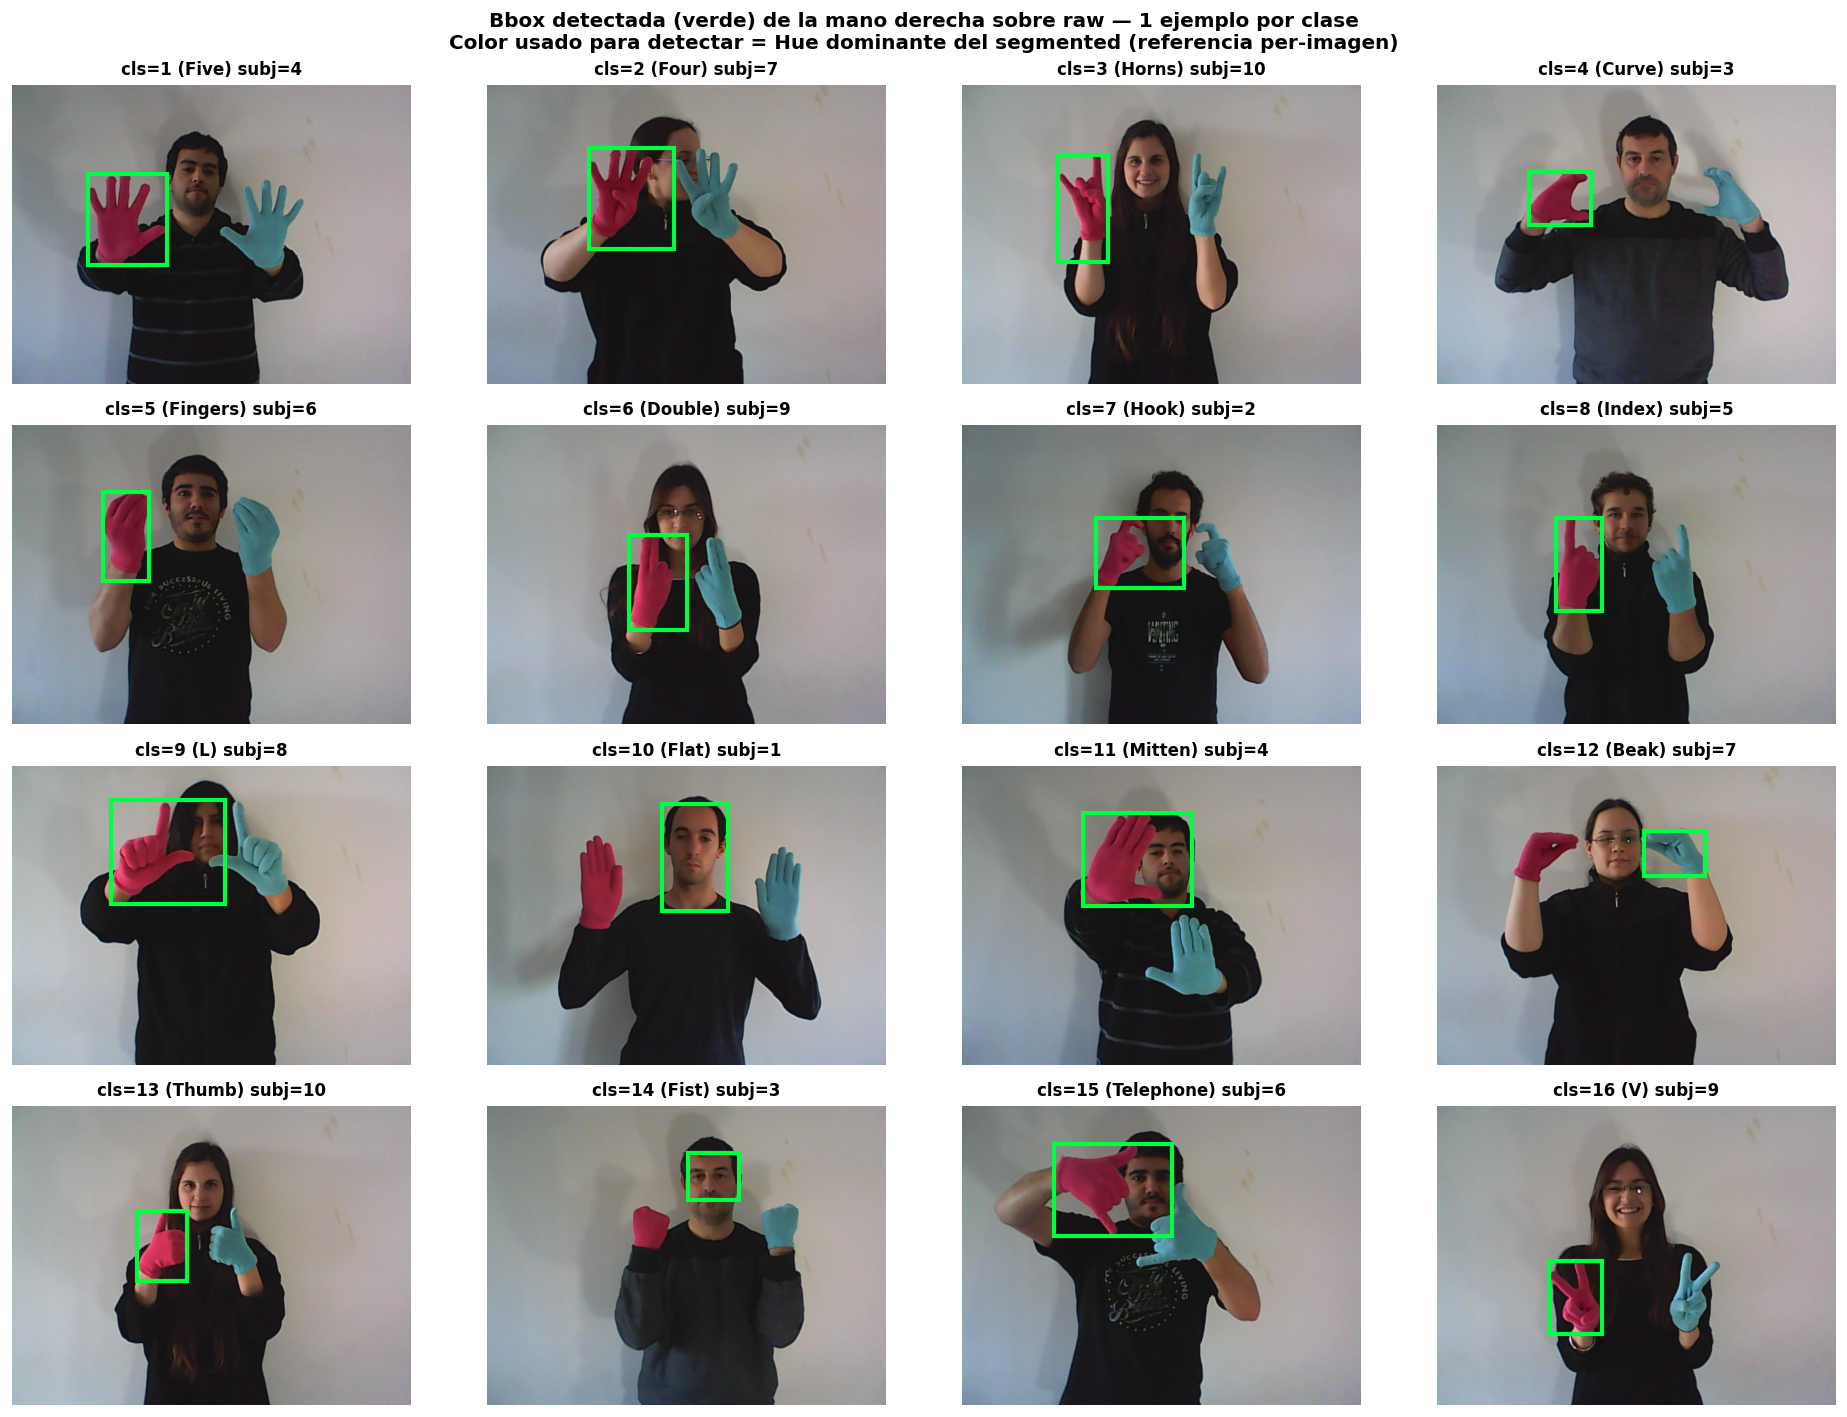

In [10]:
# Ejemplos de bboxes detectadas (1 muestra por clase)
from IPython.display import Image as IPImage

bbox_fig = PROJECT_ROOT / 'outputs' / '02_yolo-gpu' / 'figures' / 'bboxes_per_class.png'
if not bbox_fig.exists():
    # Fallback al directorio original si no se copió aún
    bbox_fig = PROJECT_ROOT / 'outputs' / '02_yolo' / 'figures' / 'bboxes_per_class.png'
IPImage(filename=str(bbox_fig))

## 11. Entrenamiento YOLOv8

Implementación en [`experiments/02_yolo_train.py`](../experiments/02_yolo_train.py) usando la API de Ultralytics.

### 11.1. Hiperparámetros y razonamiento

| Parámetro | Valor | Razón |
|---|---|---|
| Modelo base | `yolov8s.pt` | balance velocidad/precisión, 11M params (comparable a ResNet-18) |
| Pesos iniciales | COCO pretrained | transfer learning desde 1.28M imgs / 80 clases |
| `imgsz` | 640 | default Ultralytics; mantiene detalle de dedos |
| `batch` | 32 (GPU) | limitado por VRAM (3080 Ti = 12GB) |
| `epochs` | 100 (`patience=20`) | early stopping conservador |
| `optimizer` | AdamW auto, lr=0.0005 | seleccionado automáticamente |
| `fliplr` | **0.0** | CRÍTICO: flip horizontal cambia mano derecha/izquierda |
| `flipud` | **0.0** | no tiene sentido geométrico para handshapes |
| `mosaic` | **0.0** | distorsiona relación espacial (1 mano por imagen) |
| `degrees`, `translate`, `scale` | 10°, 0.1, 0.1 | jitter geométrico leve |
| `hsv_s`, `hsv_v` | 0.4, 0.3 | variación moderada de iluminación |

### 11.2. Costo computacional

| Hardware | yolov8s, 88 épocas (con early stop) |
|---|---:|
| Mac M3 Pro (CPU) | ~3-5 horas estimadas |
| **RTX 3080 Ti (GPU)** | **8.5 minutos** |

Speedup ~20×. Los entrenamientos definitivos se hicieron en GPU.

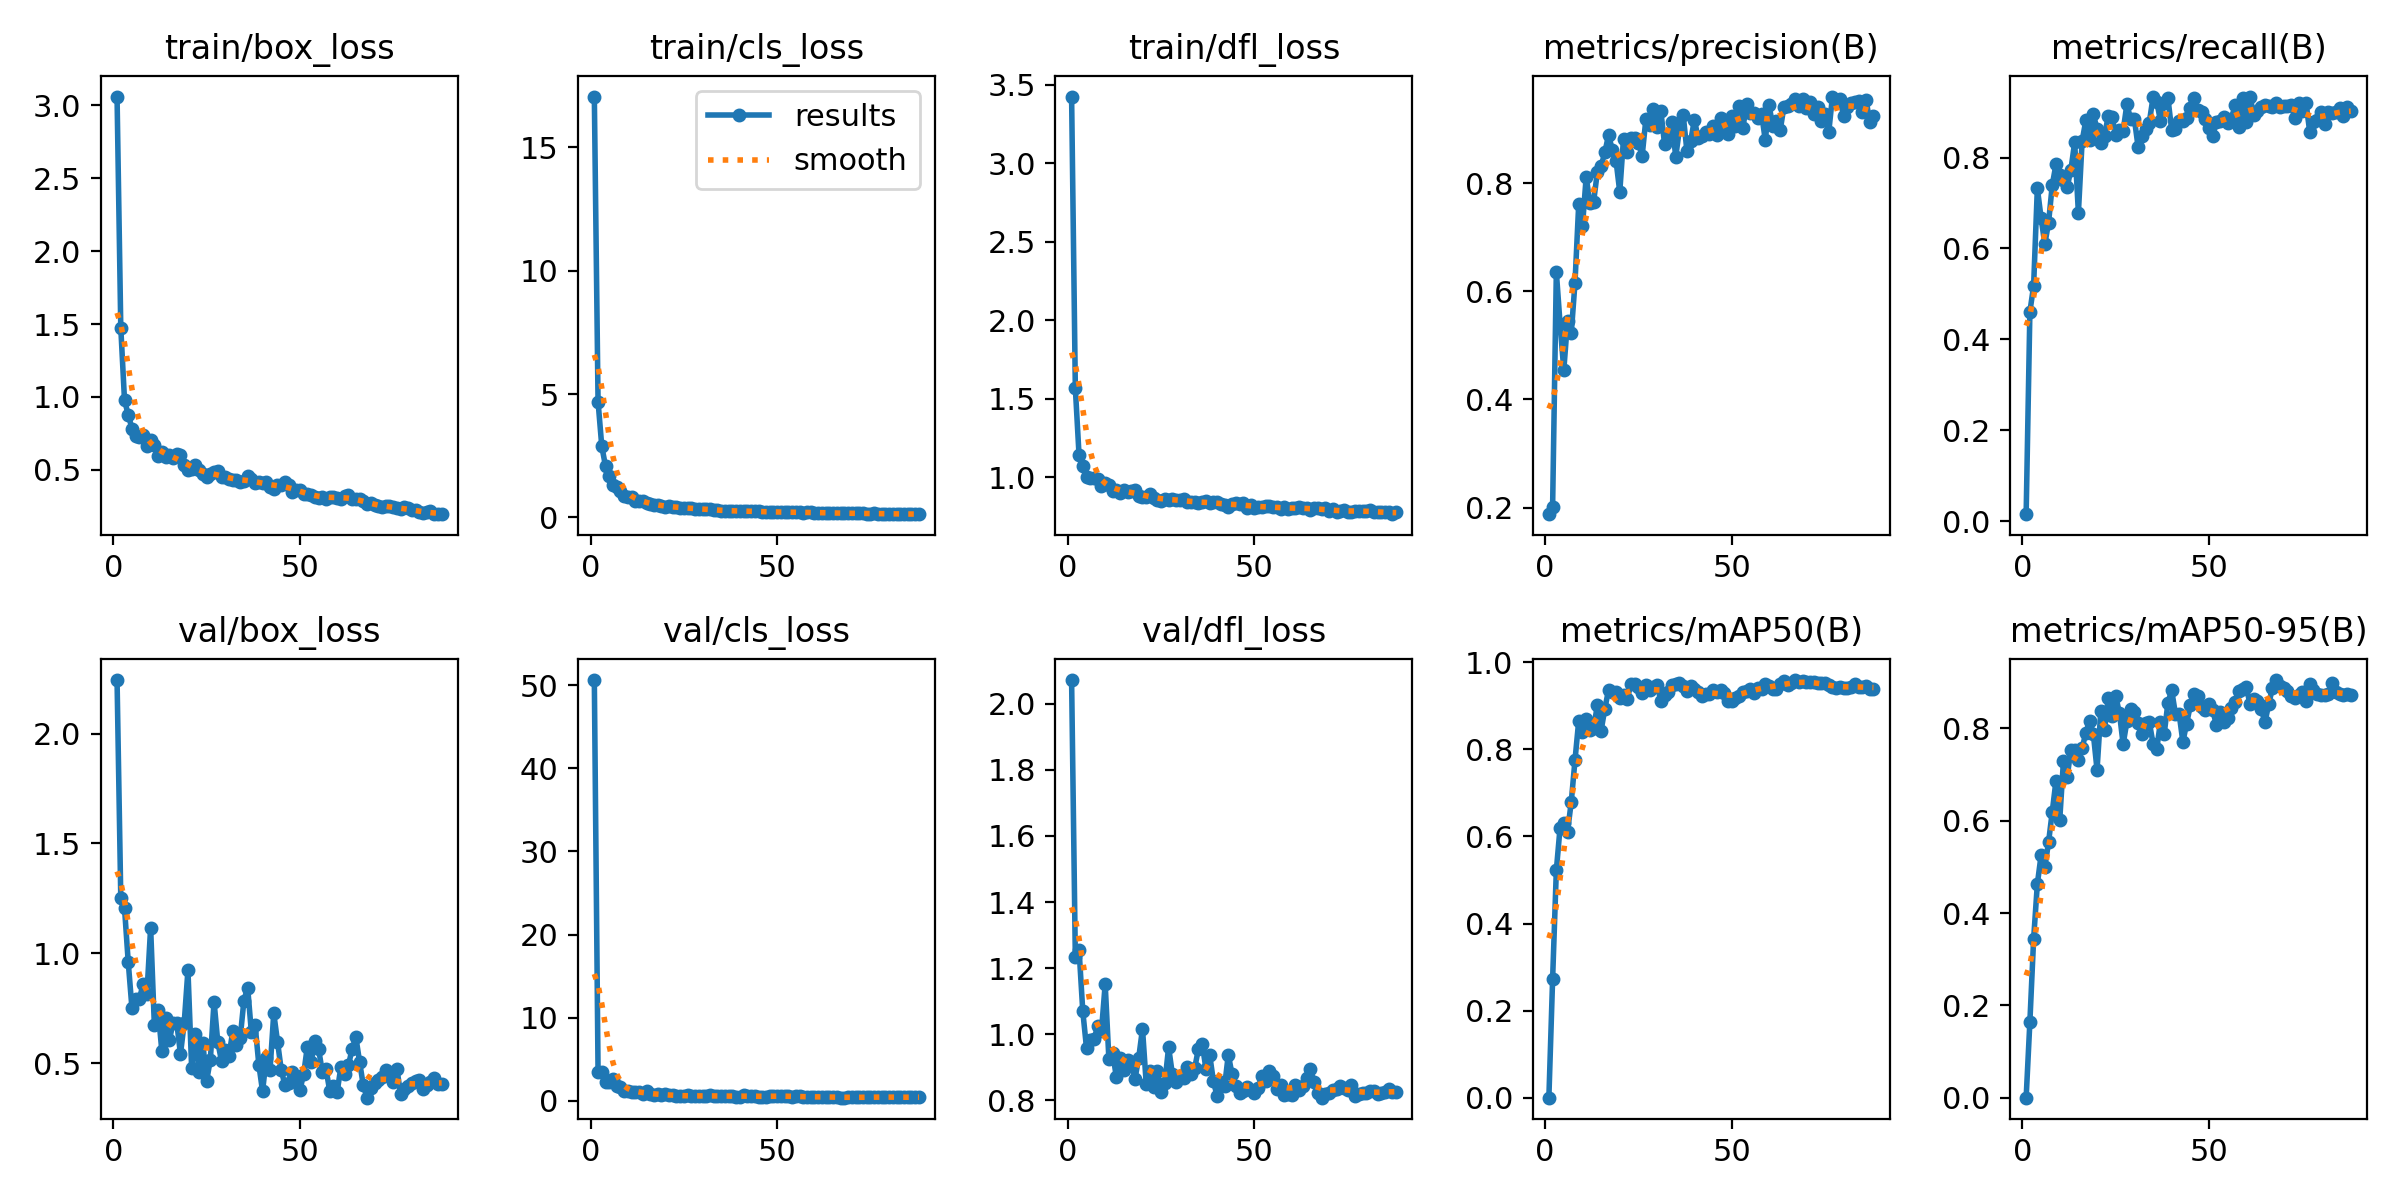

In [11]:
# Curvas de entrenamiento de YOLOv8s
training_curves = PROJECT_ROOT / 'outputs' / '02_yolo-gpu' / 'yolov8s_gpu' / 'results.png'
IPImage(filename=str(training_curves))

## 12. Resultados YOLOv8

Métricas calculadas sobre el split de test (117 imágenes) usando [`experiments/02_yolo_eval.py`](../experiments/02_yolo_eval.py).

In [12]:
# Cargar métricas de eval para ambas variantes
import json

eval_s_path = PROJECT_ROOT / 'outputs' / '02_yolo-gpu' / 'eval_yolov8s_gpu.json'
eval_m_path = PROJECT_ROOT / 'outputs' / '02_yolo-gpu' / 'eval_yolov8m_imgsz960-2.json'

eval_s = json.load(open(eval_s_path))
eval_m = json.load(open(eval_m_path))

yolo_results = pd.DataFrame([
    {
        'Modelo': 'YOLOv8s @ 640',
        'Detection rate': f"{eval_s['detection_rate']*100:.1f}%",
        'Acc (todas)': f"{eval_s['classification_accuracy']*100:.2f}%",
        'Acc (detectadas)': f"{eval_s['classification_accuracy_detected_only']*100:.2f}%",
        'IoU mediana': f"{eval_s['median_iou']:.3f}",
        'mAP@50': f"{eval_s['mAP50']:.3f}",
        'mAP@50-95': f"{eval_s['mAP50_95']:.3f}",
    },
    {
        'Modelo': 'YOLOv8m @ 960',
        'Detection rate': f"{eval_m['detection_rate']*100:.1f}%",
        'Acc (todas)': f"{eval_m['classification_accuracy']*100:.2f}%",
        'Acc (detectadas)': f"{eval_m['classification_accuracy_detected_only']*100:.2f}%",
        'IoU mediana': f"{eval_m['median_iou']:.3f}",
        'mAP@50': f"{eval_m['mAP50']:.3f}",
        'mAP@50-95': f"{eval_m['mAP50_95']:.3f}",
    },
])
yolo_results

,Modelo,Detection rate,Acc (todas),Acc (detectadas),IoU mediana,mAP@50,mAP@50-95
0,YOLOv8s @ 640,94.9%,89.74%,94.59%,0.818,0.923,0.875
1,YOLOv8m @ 960,98.3%,90.60%,92.17%,0.949,0.925,0.864


### 12.1. Matriz de confusión (yolov8s)

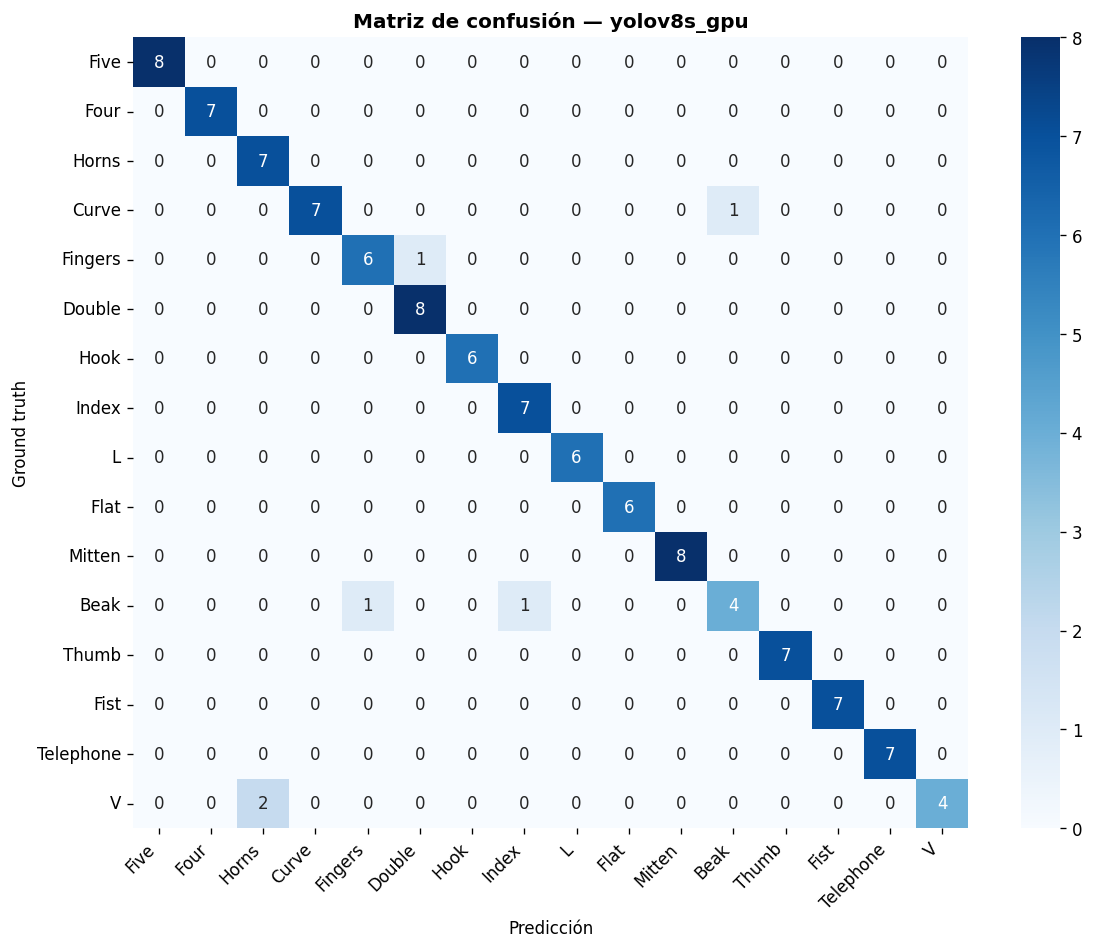

In [13]:
cm_path = PROJECT_ROOT / 'outputs' / '02_yolo-gpu' / 'figures' / 'confusion_yolov8s_gpu.png'
IPImage(filename=str(cm_path))

**Observaciones**:

- **11 de 16 clases** con clasificación perfecta.
- Confusiones más frecuentes: **V→Horns (2 errores)**, Beak→Fingers/Index (1 c/u), Curve→Beak (1).
- Las confusiones son entre clases **visualmente similares**: V y Horns son ambas configuraciones con 2 dedos extendidos en horquilla. Beak, Fingers e Index son poses cerradas con punta visible.

### 12.2. Distribución de IoU (calidad de localización)

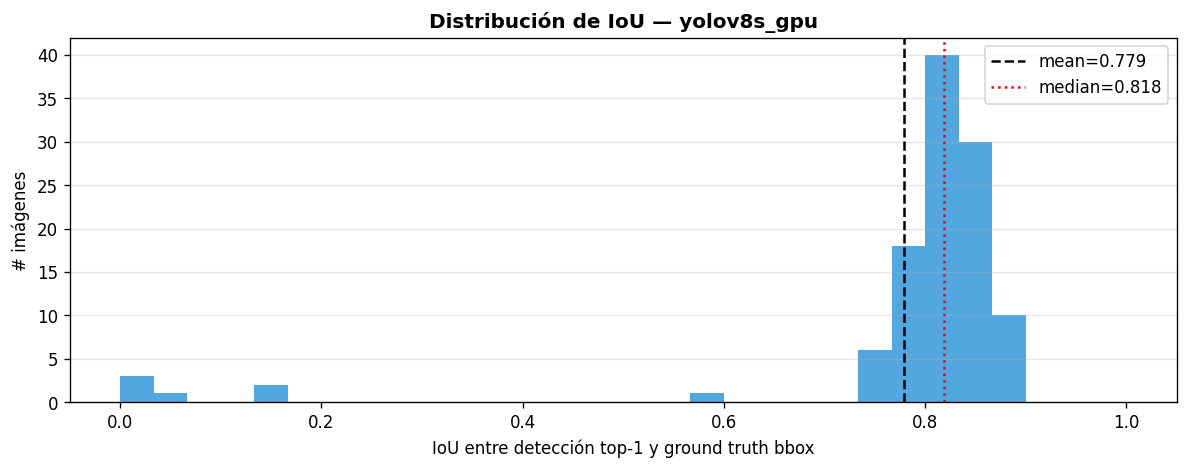

In [14]:
iou_path = PROJECT_ROOT / 'outputs' / '02_yolo-gpu' / 'figures' / 'iou_distribution_yolov8s_gpu.png'
IPImage(filename=str(iou_path))

La gran mayoría de las detecciones tienen **IoU ≥ 0.75** con mediana 0.82. Los pocos outliers con IoU < 0.6 corresponden a casos difíciles que explican parte de la diferencia entre acc-global y acc-cuando-detecta.

### 12.3. Ablación: ¿más capacidad mejora el resultado?

Probamos una variante más ambiciosa (yolov8m + imgsz=960) — modelo más grande Y mayor resolución de entrada — para testear si el accuracy mejora:

In [15]:
comparison = pd.DataFrame([
    {'Métrica': 'Detection rate',         'yolov8s @ 640': '94.9% (6 misses)', 'yolov8m @ 960': '98.3% (2 misses)', 'Δ': '+3.4pp ✅'},
    {'Métrica': 'Acc global (todas)',     'yolov8s @ 640': '89.74%',           'yolov8m @ 960': '90.60%',           'Δ': '+0.86pp'},
    {'Métrica': 'Acc (solo detectadas)',  'yolov8s @ 640': '94.59%',           'yolov8m @ 960': '92.17%',           'Δ': '−2.42pp ❌'},
    {'Métrica': 'IoU promedio',           'yolov8s @ 640': '0.779',            'yolov8m @ 960': '0.899',            'Δ': '+12pp ✅'},
    {'Métrica': 'IoU mediana',            'yolov8s @ 640': '0.818',            'yolov8m @ 960': '0.949',            'Δ': '+13pp ✅'},
    {'Métrica': 'mAP@50',                 'yolov8s @ 640': '0.923',            'yolov8m @ 960': '0.925',            'Δ': '≈'},
    {'Métrica': 'mAP@50-95',              'yolov8s @ 640': '0.875',            'yolov8m @ 960': '0.864',            'Δ': '−1.1pp'},
    {'Métrica': 'Tiempo entrenamiento',   'yolov8s @ 640': '8.5 min',          'yolov8m @ 960': '39.7 min',         'Δ': '4.7× más'},
])
comparison

,Métrica,yolov8s @ 640,yolov8m @ 960,Δ
0,Detection rate,94.9% (6 misses),98.3% (2 misses),+3.4pp ✅
1,Acc global (todas),89.74%,90.60%,+0.86pp
2,Acc (solo detectadas),94.59%,92.17%,−2.42pp ❌
3,IoU promedio,0.779,0.899,+12pp ✅
4,IoU mediana,0.818,0.949,+13pp ✅
5,mAP@50,0.923,0.925,≈
6,mAP@50-95,0.875,0.864,−1.1pp
7,Tiempo entrenamiento,8.5 min,39.7 min,4.7× más


**Hallazgo metodológico interesante**: más capacidad **NO mejoró la clasificación**, e incluso la empeoró ligeramente (−2.42pp en acc-cuando-detecta). Lo que sí mejoró drásticamente fue:

- **Localización**: IoU mediana 0.82 → 0.95.
- **Cobertura**: 4 misses menos (detection rate 94.9% → 98.3%).

**Interpretación**: el cuello de botella ya no es la capacidad del modelo, sino la **similitud visual intrínseca** entre algunas configuraciones manuales. Más parámetros (26M de yolov8m, 47k params por sample de train) generan **sobreajuste leve** sobre las 556 imágenes de entrenamiento.

**Para la tesis: reportamos yolov8s como modelo principal** (mejor classification y más liviano), y yolov8m como ablation negativa — un resultado científicamente valioso que confirma que *más no siempre es mejor* en datasets pequeños.

## 13. Comparación final: CNN baseline vs YOLO detector espacial

### 13.1. Tabla unificada de todos los modelos experimentados

In [16]:
final = pd.DataFrame([
    {'Modelo': 'LeNet (paper, 100 runs)',         'Input': 'mano segmentada + canonical 128×128', 'Accuracy': '96.18%',         'Notas': 'benchmark del paper'},
    {'Modelo': 'LeNet (nuestra réplica, 10 runs)','Input': 'mano segmentada + canonical 128×128', 'Accuracy': '91.25% ± 7.83%', 'Notas': 'varianza honesta'},
    {'Modelo': 'LeNet + augment (10 runs)',       'Input': 'mano segmentada + canonical 128×128', 'Accuracy': '91.62% ± 6.71%', 'Notas': 'hipótesis refutada'},
    {'Modelo': 'ResNet-18 transfer (10 runs)',    'Input': 'mano segmentada + canonical 128×128', 'Accuracy': '97.62% ± 1.63%', 'Notas': 'supera al paper'},
    {'Modelo': 'LeNet sobre raw (10 runs)',       'Input': 'imagen completa 640×480',             'Accuracy': '22.12% ± 5.76%', 'Notas': 'CNN colapsa sin preproc.'},
    {'Modelo': '**YOLOv8s sobre raw**',           'Input': '**imagen completa 640×480**',         'Accuracy': '**89.74%**',     'Notas': '**modelo principal**'},
    {'Modelo': 'YOLOv8m @ 960 sobre raw',         'Input': 'imagen completa 640×480',             'Accuracy': '90.60%',         'Notas': 'ablation: más ≠ mejor'},
])
final

,Modelo,Input,Accuracy,Notas
0,"LeNet (paper, 100 runs)",mano segmentada + canonical 128×128,96.18%,benchmark del paper
1,"LeNet (nuestra réplica, 10 runs)",mano segmentada + canonical 128×128,91.25% ± 7.83%,varianza honesta
2,LeNet + augment (10 runs),mano segmentada + canonical 128×128,91.62% ± 6.71%,hipótesis refutada
3,ResNet-18 transfer (10 runs),mano segmentada + canonical 128×128,97.62% ± 1.63%,supera al paper
4,LeNet sobre raw (10 runs),imagen completa 640×480,22.12% ± 5.76%,CNN colapsa sin preproc.
5,**YOLOv8s sobre raw**,**imagen completa 640×480**,**89.74%**,**modelo principal**
6,YOLOv8m @ 960 sobre raw,imagen completa 640×480,90.60%,ablation: más ≠ mejor


### 13.2. Análisis cualitativo

La tabla cuenta dos historias según en qué eje focalicemos:

**Sobre la mano preprocesada** (canonical 128×128):
- ResNet-18 (97.62%) supera a LeNet (91-96%). Transfer learning resuelve la inestabilidad de entrenamiento del CNN puramente entrenado desde cero.
- La comparación se reduce a *"qué arquitectura clasifica mejor sobre un crop limpio"*.

**Sobre el escenario realista** (imagen completa 640×480 sin preprocesamiento):
- LeNet colapsa a **22.12%** — apenas mejor que random (6.25%) pero inviable como sistema.
- YOLOv8s alcanza **89.74%** — **una diferencia de +67pp** respecto a LeNet en la misma entrada.
- YOLOv8m apenas mejora a 90.60%, confirmando que estamos cerca del techo del enfoque YOLO para este dataset.

**La diferencia de +67pp en el escenario realista es la contribución principal del trabajo**: el cambio de paradigma de clasificación a detección espacial habilita el procesamiento de imágenes no controladas, donde el CNN tradicional fracasa.

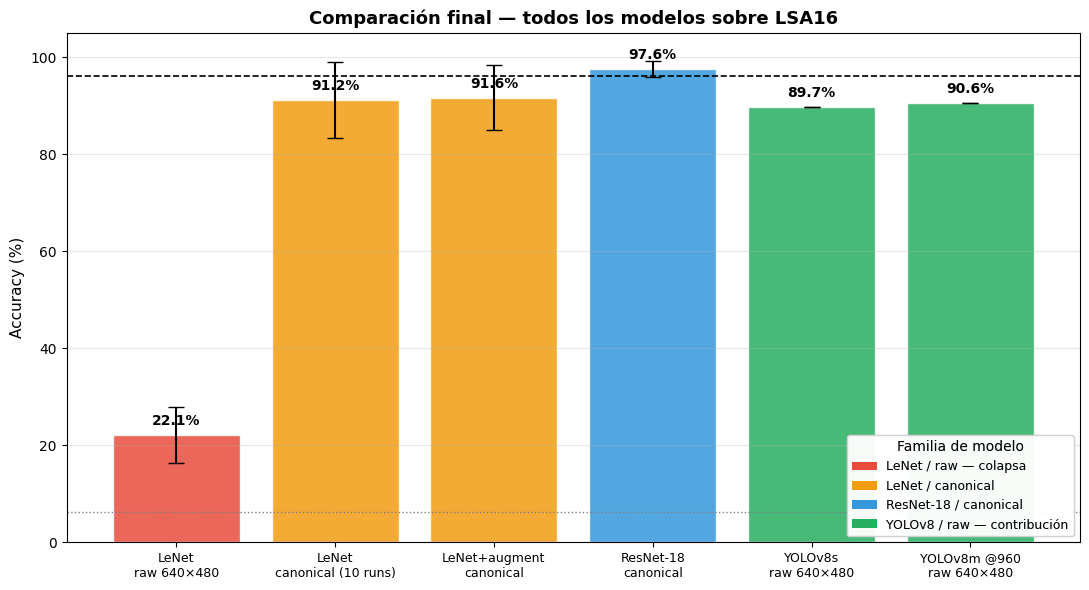

In [17]:
# Visualización gráfica de la comparación final
fig, ax = plt.subplots(figsize=(11, 6))

data = [
    ('LeNet\nraw 640×480',          22.12,  5.76, '#E74C3C'),
    ('LeNet\ncanonical (10 runs)',  91.25,  7.83, '#F39C12'),
    ('LeNet+augment\ncanonical',    91.62,  6.71, '#F39C12'),
    ('ResNet-18\ncanonical',        97.62,  1.63, '#3498DB'),
    ('YOLOv8s\nraw 640×480',        89.74,  0.0,  '#27AE60'),
    ('YOLOv8m @960\nraw 640×480',   90.60,  0.0,  '#27AE60'),
]
labels  = [d[0] for d in data]
means   = [d[1] for d in data]
stds    = [d[2] for d in data]
colors  = [d[3] for d in data]

x = np.arange(len(data))
bars = ax.bar(x, means, yerr=stds, capsize=6, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(y=96.18, color='black', ls='--', lw=1.2,
           label='Paper benchmark LeNet=96.18%')
ax.axhline(y=6.25, color='gray', ls=':', lw=1.0, label='Random (1/16=6.25%)')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_ylim(0, 105)
ax.set_title('Comparación final — todos los modelos sobre LSA16',
             fontsize=13, fontweight='bold')
ax.legend(loc='center right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 2, f'{m:.1f}%',
            ha='center', fontsize=10, fontweight='bold')
# Rótulos por color
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', label='LeNet / raw — colapsa'),
    Patch(facecolor='#F39C12', label='LeNet / canonical'),
    Patch(facecolor='#3498DB', label='ResNet-18 / canonical'),
    Patch(facecolor='#27AE60', label='YOLOv8 / raw — contribución'),
]
leg2 = ax.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Familia de modelo')
ax.add_artist(leg2)
plt.tight_layout()
plt.show()

## 14. Conclusiones finales y trabajo futuro

### 14.1. Síntesis del trabajo

Este notebook documenta el camino completo desde la replicación del paper hasta una propuesta original con detección espacial. Hallazgos principales:

1. **Replicación reproducible** del baseline LeNet del paper (95.83% obtenido vs 96.18% target en 3 runs, indistinguible dentro del ruido), con el **preprocesamiento canónico identificado como ingrediente crítico** que el paper no documenta explícitamente.
2. **Caracterización honesta de la varianza** (10 runs muestran inestabilidad de entrenamiento de LeNet que el paper diluye con 100 runs).
3. **Mejora sobre el paper con ResNet-18 transfer learning**: 97.62% ± 1.63%, superando el benchmark publicado por +1.44pp y reduciendo la varianza 4.8×.
4. **Refutación con rigor de la hipótesis "augmentation arregla la inestabilidad"**: no la elimina, solo cambia qué semillas son problemáticas.
5. **Pipeline automático de generación de anotaciones YOLO** vía template matching enmascarado (99.25% de éxito), con identificación y corrección del problema de falsos positivos en regiones faciales que tenía el enfoque por color HSV.
6. **YOLOv8s sobre raw alcanza 89.74% accuracy y mAP@50=0.923**, con **+67pp sobre LeNet** en la misma entrada. Esta es la contribución central del trabajo.
7. **Ablación negativa con yolov8m+imgsz=960**: mejora drásticamente la localización (IoU mediana 0.82 → 0.95) pero **no la clasificación** (sobreajuste leve). Resultado científicamente útil que orienta futuras decisiones de modelo para datasets pequeños.

### 14.2. Trabajo futuro identificado

1. **Evaluación LOSO** (leave-one-subject-out) sobre los modelos finales (ResNet-18, YOLOv8s) — protocolo más riguroso donde el sujeto de test nunca está en train. Mediría la capacidad de generalizar a usuarios no vistos durante el entrenamiento (típicamente cae 10-15pp pero es más representativo del uso real).
2. **ResNet-18 + data augmentation**: combinación no testeada. Hipótesis: podría llevar el accuracy CNN cerca del 99%. Costo: ~90 min de GPU. No se ejecutó por priorizar el contraste con YOLO.
3. **YOLOv8n** (nano): modelo más liviano para deployment en tiempo real en hardware modesto (webcam de notebook, mobile).
4. **Test end-to-end con webcam real**: validar el pipeline en condiciones no controladas (iluminación variable, fondo no blanco, distancia variable).

### 14.3. Reproducibilidad

Para reproducir cualquier resultado de este notebook:

```bash
cd trabajo-parcial
source .venv/bin/activate

# CNN baselines (canonical preprocessing) — total ~2.5 hs CPU
python scripts/preprocess_canonical.py
python experiments/01_baseline_paper.py --mode canonical --n-runs 10
python experiments/01_baseline_paper.py --mode canonical --augment --n-runs 10
python experiments/01_baseline_paper.py --mode canonical --model resnet18 --n-runs 10
python experiments/01_baseline_paper.py --mode raw --n-runs 10

# YOLO pipeline (~10 min en GPU NVIDIA, ~3-5 hs en CPU)
python scripts/generate_yolo_dataset.py
python experiments/02_yolo_train.py --model yolov8s.pt --imgsz 640 --device 0
python experiments/02_yolo_eval.py --weights outputs/02_yolo/yolov8s_*/weights/best.pt
```

Todos los resultados se loguean en `outputs/01_baseline/results.jsonl` y `outputs/02_yolo*/results.jsonl` (machine-readable). El notebook lee de estos archivos en tiempo de ejecución, así que **regenerarlo** después de nuevos experimentos solo requiere re-ejecutar las celdas.